In [1]:
import mmbra
import mmbracategories

import torch
import os
import scipy.io as sio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Code from Google Collab



# load data
data_dir_root = os.path.join('./data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'

# getting directory and joining that
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

# Data Loading

# set up directory by constructing data paths to the data sets
# organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
# datasets are loaded from .mat files using the scipy.io.loadmat() function.
# function reads the data into numpy arrays, facilitating data manipulation.


# Data Preprocessing

# For the brain data, specific time intervals are extracted and the data is reshaped to a two-dimensional format to simplify analysis
# Image and text data are scaled to enhance numerical stability during model training
# Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity

# Conversion to PyTorch Tensors

# The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. 
# This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

# Summary 

# The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. 
# This summary helps confirm that the data is correctly formatted and that the expected number of features is present. 
# This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [3]:
#brain

#BRAIN_SEEN
brain_seen_df = pd.DataFrame(brain_seen.numpy())  # Convert PyTorch tensor to DataFrame if needed


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA
lda = LinearDiscriminantAnalysis()
reduced_brain_data = lda.fit_transform(brain_seen_df, label_seen)

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
# Convert PyTorch tensor to NumPy if needed
seen_label_np = label_seen.numpy().ravel()  # Replace with your actual label variable

In [6]:
reduced_brain_data.shape

(16540, 561)

In [7]:
#MAKING MIC to find top 20 columns

# Compute mutual information between PCA components and labels
mi_scores = mutual_info_classif(reduced_brain_data, seen_label_np)

# Create a DataFrame for easier interpretation
mi_df = pd.DataFrame({'Feature': [f'LD{i+1}' for i in range(reduced_brain_data.shape[1])], 'MI Score': mi_scores})

# Sort features by MI score
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

    Feature  MI Score
0       LD1  0.585118
1       LD2  0.526936
2       LD3  0.480400
3       LD4  0.450314
4       LD5  0.369864
..      ...       ...
378   LD379  0.000000
379   LD380  0.000000
380   LD381  0.000000
381   LD382  0.000000
560   LD561  0.000000

[561 rows x 2 columns]


In [8]:
# Threshold and selected components
threshold = np.percentile(mi_scores, 75)
selected_components = np.where(mi_scores > threshold)[0]
print(f"Selected LDA components: {selected_components}")

# Filter the LDA-transformed dataset using these indices
brain_selected_components_data = reduced_brain_data[:, selected_components]
print(f"Filtered Data Shape: {brain_selected_components_data.shape}")

Selected LDA components: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 125 126 128
 129 130 132 133 134 135 137 138 139 141 143 144 149 155]
Filtered Data Shape: (16540, 140)


In [9]:
brain_selected_components_data = torch.from_numpy(brain_selected_components_data)

In [10]:
# Image

#IMAGE_SEEN
image_seen_df = pd.DataFrame(image_seen.numpy())  # Convert PyTorch tensor to DataFrame if needed


In [11]:
# Initialize LDA
lda = LinearDiscriminantAnalysis()
reduced_image_data = lda.fit_transform(image_seen_df, label_seen)

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [12]:
#MAKING MIC to find top 20 columns

# Compute mutual information between PCA components and labels
mi_scores = mutual_info_classif(reduced_image_data, seen_label_np)

# Create a DataFrame for easier interpretation
mi_df = pd.DataFrame({'Feature': [f'LD{i+1}' for i in range(reduced_image_data.shape[1])], 'MI Score': mi_scores})

# Sort features by MI score
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

   Feature  MI Score
0      LD1  0.946026
1      LD2  0.794252
2      LD3  0.690743
3      LD4  0.638638
5      LD6  0.570179
..     ...       ...
84    LD85  0.028425
69    LD70  0.028422
70    LD71  0.027714
77    LD78  0.024673
86    LD87  0.024204

[100 rows x 2 columns]


In [13]:
# Threshold and selected components
threshold = np.percentile(mi_scores, 75)
selected_components = np.where(mi_scores > threshold)[0]
print(f"Selected PCA components: {selected_components}")

# Filter the LDA-transformed dataset using these indices
image_selected_components_data = reduced_image_data[:, selected_components]
print(f"Filtered Data Shape: {image_selected_components_data.shape}")

Selected PCA components: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Filtered Data Shape: (16540, 25)


In [14]:
image_selected_components_data = torch.from_numpy(image_selected_components_data)

In [15]:
# Text

#TEXT_SEEN
text_seen_df = pd.DataFrame(text_seen.numpy())  # Convert PyTorch tensor to DataFrame if needed


In [16]:
# Initialize LDA
lda = LinearDiscriminantAnalysis()
reduced_text_data = lda.fit_transform(text_seen_df, label_seen)

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [17]:
# Convert PyTorch tensor to NumPy if needed
seen_label_np = label_seen.numpy().ravel()  # Replace with your actual label variable

In [18]:
#MAKING MIC to find top 20 columns

# Compute mutual information between LDA components and labels
mi_scores = mutual_info_classif(reduced_text_data, seen_label_np)

# Create a DataFrame for easier interpretation
mi_df = pd.DataFrame({'Feature': [f'LD{i+1}' for i in range(reduced_text_data.shape[1])], 'MI Score': mi_scores})

# Sort features by MI score
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

    Feature  MI Score
0       LD1  1.614596
2       LD3  1.457130
3       LD4  1.442585
4       LD5  1.410922
1       LD2  1.396062
..      ...       ...
503   LD504  0.305889
504   LD505  0.305493
502   LD503  0.301823
499   LD500  0.297108
508   LD509  0.286644

[511 rows x 2 columns]


In [19]:
# Threshold and selected components
threshold = np.percentile(mi_scores, 75)
selected_components = np.where(mi_scores > threshold)[0]
print(f"Selected LDA components: {selected_components}")

# Filter the PCA-transformed dataset using these indices
text_selected_components_data = reduced_text_data[:, selected_components]
print(f"Filtered Data Shape: {text_selected_components_data.shape}")

Selected LDA components: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 130 131]
Filtered Data Shape: (16540, 128)


In [20]:
text_selected_components_data = torch.from_numpy(text_selected_components_data)

In [21]:
#Use 20 categories
index_seen = np.squeeze(np.where(label_seen < 21, True, False))
index_unseen = np.squeeze(np.where(label_unseen < 21, True, False))

brain_seen = brain_selected_components_data[index_seen, :]
image_seen = image_selected_components_data[index_seen, :]
text_seen = text_selected_components_data[index_seen, :]
label_seen = label_seen[index_seen]

brain_unseen = brain_unseen[index_unseen, :]
image_unseen = image_unseen[index_unseen, :]
text_unseen = text_unseen[index_unseen, :]
label_unseen = label_unseen[index_unseen]

#The ThingsEEG-Text dataset is mainly designed and used for Zero-Shot type research work, because the independence of its training set and test set
#in categories is very suitable for this task. If it needs to be used for other types of tasks
#(such as general classification or cross-modal learning),
#the data may need to be repartitioned. Therefore, we repartition the dataset to make it better for our task
#Define the number of classes and the number of samples per class
num_classes = 20
samples_per_class = 10

import torch
#For each class, take the first 5 images as training and the last 5 images as testing
new_train_brain = []
new_train_image = []
new_train_text = []
new_train_label = []

new_test_brain = []
new_test_image = []
new_test_text = []
new_test_label = []

# Convert numpy arrays to PyTorch tensors before appending
for i in range(num_classes):
    start_idx = i * samples_per_class  # The starting index of the current class
    end_idx = start_idx + samples_per_class  # The end index of the current class

    # Get the data of the current class
    class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_brain.append(class_data_brain[:6])
    new_test_brain.append(class_data_brain[6:])

    class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_image.append(class_data_image[:6])
    new_test_image.append(class_data_image[6:])

    class_data_text = torch.tensor(text_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_text.append(class_data_text[:6])
    new_test_text.append(class_data_text[6:])

    class_data_label = torch.tensor(label_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_label.append(class_data_label[:6])
    new_test_label.append(class_data_label[6:])

# Stack the tensors
train_brain = torch.vstack(new_train_brain)
train_image = torch.vstack(new_train_image)
train_text = torch.vstack(new_train_text)
train_label = torch.vstack(new_train_label)
test_brain = torch.vstack(new_test_brain)
test_image = torch.vstack(new_test_image)
test_text = torch.vstack(new_test_text)
test_label = torch.vstack(new_test_label)

# Print shapes
print(train_brain.shape)
print(train_image.shape)
print(train_text.shape)
print(train_label.shape)
print(test_brain.shape)
print(test_image.shape)
print(test_text.shape)
print(test_label.shape)

torch.Size([120, 140])
torch.Size([120, 25])
torch.Size([120, 128])
torch.Size([120, 1])
torch.Size([80, 140])
torch.Size([80, 25])
torch.Size([80, 128])
torch.Size([80, 1])


/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_97125/102942923.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_97125/102942923.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_97125/102942923.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sou

Ensemble Model Accuracy: 0.9375
Ensemble Model Precision: 0.9533333333333334
Ensemble Model Recall: 0.9375
Ensemble Model F1-Score: 0.9352380952380953
Confusion Matrix:
[[4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0]
 [0 1 0 0 0 0 

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


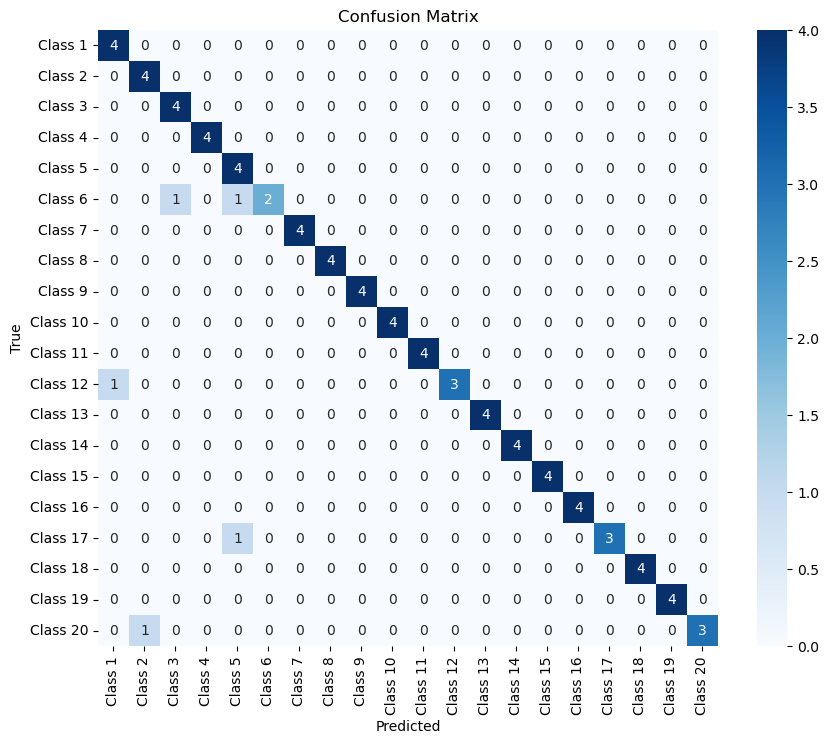

In [27]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Define the individual models
svm_brain = SVC(kernel='rbf', probability=True)  # probability=True for soft voting
svm_text = SVC(kernel='linear', probability=True)
svm_image = SVC(kernel='linear', probability=True)  # Assuming you have an image model

# Train the individual models on their respective datasets
svm_brain.fit(train_brain, train_label)
svm_text.fit(train_text, train_label)
svm_image.fit(train_image, train_label)

# Create the ensemble model using VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[
        ('brain', svm_brain),
        ('text', svm_text),
        ('image', svm_image)
    ],
    voting='hard'  # 'hard' for majority voting, 'soft' for weighted voting
)

brain_pred = svm_brain.predict(test_brain)
text_pred = svm_text.predict(test_text)
image_pred = svm_image.predict(test_image)

# Combine the predictions for the final ensemble prediction
ensemble_pred = np.array([brain_pred, text_pred, image_pred])
final_pred = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_pred)

# Evaluate the ensemble model
accuracy = accuracy_score(test_label, final_pred)
precision = precision_score(test_label, final_pred, average='weighted')  # Use 'weighted' for multi-class classification
recall = recall_score(test_label, final_pred, average='weighted')
f1 = f1_score(test_label, final_pred, average='weighted')
conf_matrix = confusion_matrix(test_label, final_pred)

print(f"Ensemble Model Accuracy: {accuracy}")
print(f"Ensemble Model Precision: {precision}")
print(f"Ensemble Model Recall: {recall}")
print(f"Ensemble Model F1-Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

num_classes = len(np.unique(train_label))  # Update based on your labels
class_names = [f"Class {i+1}" for i in range(num_classes)]

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()